# Ajedrez online — Entrega 3 (avance): predicción en vivo por cortes y matchup de apertura

Este notebook responde dos pedidos del profesor para la Entrega 3:

1. **Predicción en vivo.** ¿Cuánto mejora la predicción del resultado a medida que avanza la partida? Se pasa de una fila por partida a una fila por **(partida, corte)**, con cortes a los 10, 20, 30, 40 y 60 medio-movimientos (plies). En cada corte sólo se usa lo que un observador podía ver en ese instante: la posición y los relojes.
2. **Histórico de matchups de apertura.** Para cada partida, la tasa histórica de victoria blanca, tablas y victoria negra de su combinación *primera jugada de blancas × respuesta de negras*, calculada **sólo con partidas terminadas antes de que la actual empezara**.

Es un avance y no la entrega final. Los modelos son baselines de gradient boosting con hiperparámetros por defecto, pensados para medir cuánta señal aporta cada grupo de variables, no para maximizar una métrica.

**Fuente.** El Parquet tidy (`partidas_ajedrez_clean.parquet`, 35 columnas) y la tabla derivada `partidas_cortes.parquet`, que construye `src/live_features.py` reproduciendo cada partida con python-chess desde el PGN crudo. Las dos las genera el pipeline (`python -m src.pipeline --skip-download` o el DAG).

## 1 · Configuración y carga

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, f1_score, log_loss, mean_absolute_error, recall_score

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.player_selection import load_selection
from src.rating_history import add_prior_ratings, reconstruct_prior_ratings
from src.utils import load_config

config = load_config(PROJECT_ROOT / "config" / "config.yaml")
RANDOM_STATE = config["processing"]["random_state"]
CUTS = config["live_prediction"]["cortes_ply"]
RESULT_ORDER = ["Gana Blancas", "Empate", "Gana Negras"]
# sklearn's log_loss assumes probability columns in sorted label order: every
# probability matrix in this notebook uses PROBA_ORDER, never RESULT_ORDER.
PROBA_ORDER = sorted(RESULT_ORDER)
TIME_ORDER = ["bullet", "blitz", "rapid"]
MODEL_COLORS = {"M0 · frecuencias": "#9e9e9e", "M1 · pre-partida": "#ed7d31", "M2 · en vivo": "#4472c4", "M3 · en vivo + matchup": "#70ad47"}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

games = pd.read_parquet(PROJECT_ROOT / config["paths"]["clean_parquet"])
cuts = pd.read_parquet(PROJECT_ROOT / config["paths"]["cortes_parquet"])
print(f"Partidas (tidy): {games.shape[0]:,} × {games.shape[1]} columnas")
print(f"Filas (partida, corte): {cuts.shape[0]:,} × {cuts.shape[1]} columnas")

Partidas (tidy): 76,803 × 35 columnas
Filas (partida, corte): 336,001 × 27 columnas


## 2 · Verificación del dataset de cortes

Antes de modelar se comprueba que la tabla derivada sea lo que dice ser:

- la clave `(GameUrl, corte_ply)` no se repite;
- cada partida aporta una fila por cada corte **estrictamente menor** que su `cantidad_jugadas`, porque en el ply *k* la partida tiene que seguir en curso. Se compara el conteo por corte contra el que se deduce del Parquet tidy;
- no hay nulos.

`build_cut_dataset` ya hace fallar el pipeline si alguna partida no tiene PGN crudo o si los plies que reproduce python-chess no coinciden con `cantidad_jugadas`; acá se re-verifica sobre el archivo guardado.

In [2]:
assert not cuts.duplicated(["GameUrl", "corte_ply"]).any(), "Clave (GameUrl, corte_ply) repetida"
assert cuts["GameUrl"].isin(games["GameUrl"]).all(), "Hay cortes de partidas que no están en el tidy"

expected = pd.Series({k: int((games["cantidad_jugadas"] > k).sum()) for k in CUTS}, name="esperadas")
observed = cuts["corte_ply"].value_counts().sort_index().rename("observadas")
coverage = pd.concat([expected, observed], axis=1)
coverage["% de partidas"] = 100 * coverage["observadas"] / len(games)
display(coverage)
assert (coverage["esperadas"] == coverage["observadas"]).all(), "Filas por corte distintas de las esperadas"

null_counts = cuts.isna().sum()
print("Nulos:", null_counts[null_counts > 0].to_dict() or "ninguno")
display(cuts.drop(columns=["GameUrl"]).describe().T[["min", "50%", "max"]])

,esperadas,observadas,% de partidas
10,76331,76331,99.385
20,74776,74776,97.361
30,71511,71511,93.110
40,65842,65842,85.728
60,47541,47541,61.900


Nulos: ninguno


,min,50%,max
corte_ply,10.000,30.000,60.000
plies_restantes,1.000,45.000,365.000
movilidad,1.000,36.000,67.000
promociones,0.000,0.000,2.000
material_blancas,0.000,34.000,47.000
jaques_blancas,0.000,0.000,17.000
capturas_blancas,0.000,2.000,15.000
reloj_blancas_seg,0.100,155.800,"8,237.600"
reloj_frac_blancas,0.001,0.844,2.726
gasto_reciente_blancas_seg,-55.200,14.400,"2,026.300"


**Lectura.** Las cinco coberturas coinciden exactamente con lo que se deduce de `cantidad_jugadas` (99,4 % de las partidas llegan al ply 10 y 61,9 % al ply 60). No hay nulos: las 76.803 partidas del tidy tienen relojes `%clk` completos.

**Anomalías de reloj, investigadas y conservadas:**

- `reloj_frac_*` (reloj restante sobre tiempo base) supera 1 en el 5,45 % de las filas. En el 99,9 % de esos casos el control tiene incremento, así que es acumulación de incrementos (jugar rápido en un 10+5 sube el reloj). Es esperable.
- `gasto_reciente_*` (segundos gastados en las últimas 5 jugadas propias) es negativo en 4 filas de 4 partidas, todas **sin** incremento: el reloj subió sin incremento, así que se agregó tiempo durante la partida. Son 4 de 336.001 filas y no se filtran.
- `material_no_peon_frac` llega a 1,06 y el material a 47 puntos: son coronaciones (una dama extra suma 9).

La celda siguiente cuenta las dos primeras directamente, en vez de asumirlas.

In [3]:
context = games[["GameUrl", "incremento_seg"]]
check = cuts.merge(context, on="GameUrl", how="left", validate="many_to_one")
assert len(check) == len(cuts)
above_base = (check["reloj_frac_blancas"] > 1) | (check["reloj_frac_negras"] > 1)
negative_spent = (check["gasto_reciente_blancas_seg"] < 0) | (check["gasto_reciente_negras_seg"] < 0)
print(f"Reloj sobre el tiempo base: {above_base.mean() * 100:.2f} % de las filas; con incremento: {(check.loc[above_base, 'incremento_seg'] > 0).mean() * 100:.1f} %")
print(f"Gasto reciente negativo: {int(negative_spent.sum())} filas en {check.loc[negative_spent, 'GameUrl'].nunique()} partidas; "
      f"sin incremento: {(check.loc[negative_spent, 'incremento_seg'] == 0).all()}")

Reloj sobre el tiempo base: 5.45 % de las filas; con incremento: 99.9 %
Gasto reciente negativo: 4 filas en 4 partidas; sin incremento: True


## 3 · Contexto de la partida y rating previo

La tabla de cortes sólo guarda lo que cambia jugada a jugada. El contexto fijo de la partida se une desde el tidy por `GameUrl` (relación muchos a uno), así que no se duplica en disco. Ese contexto es el ritmo, el control de tiempo, si es de torneo, el matchup de apertura y su historial, y la hora de inicio para la partición.

**Rating previo, no el del Parquet.** `WhiteElo`/`BlackElo` son el rating **posterior** a la partida y llevan el resultado adentro (sección 9 del notebook 02). `src/rating_history.py` reconstruye el rating previo: el de cada cuenta seleccionada al cierre de su partida anterior del mismo ritmo. Sólo se puede reconstruir el lado de la cuenta seleccionada. El rival casi nunca tiene historial en la muestra, así que ese lado queda **NaN, sin imputar**. El gradient boosting de sklearn maneja faltantes de forma nativa.

In [4]:
usernames = load_selection(PROJECT_ROOT / config["player_selection"]["selection_path"])
template = config["chess_com"]["raw_filename_template"]
raw_paths = {u: PROJECT_ROOT / config["paths"]["raw_dir"] / template.format(username=u) for u in usernames}
games = add_prior_ratings(games, reconstruct_prior_ratings(raw_paths))

known_white, known_black = games["elo_blancas_previo"].notna(), games["elo_negras_previo"].notna()
print(f"Rating previo de blancas: {known_white.mean() * 100:.1f} % · de negras: {known_black.mean() * 100:.1f} % · "
      f"de al menos un lado: {(known_white | known_black).mean() * 100:.1f} % · de los dos: {int((known_white & known_black).sum())} partidas")

CONTEXT_COLUMNS = [
    "GameUrl", "StartTime", "EndTime", "TimeClass", "tiempo_base_seg", "incremento_seg", "EsTorneo",
    "elo_blancas_previo", "elo_negras_previo", "WhiteElo", "BlackElo", "diferencia_elo",
    "matchup_apertura", "historial_suficiente", "tasa_blancas_hist", "tasa_tablas_hist", "tasa_negras_hist",
]
rows_before = len(cuts)
data = cuts.merge(games[CONTEXT_COLUMNS], on="GameUrl", how="left", validate="many_to_one")
assert len(data) == rows_before, "Fan-out detectado al unir el contexto de la partida"
data["TimeClass"] = pd.Categorical(data["TimeClass"].astype(str), categories=TIME_ORDER)
print(f"Filas para modelar: {len(data):,}")

2026-09-26 13:26:32 - src.rating_history - INFO - Rating previo reconstruido: blancas en 38515 partidas, negras en 38479.


Rating previo de blancas: 49.9 % · de negras: 49.8 % · de al menos un lado: 99.7 % · de los dos: 6 partidas


Filas para modelar: 336,001


**Lectura.** Casi todas las partidas tienen el rating previo de un lado, pero casi ninguna de los dos. El modelo ve la fuerza de uno de los jugadores y no la del otro. Esto es menos grave de lo que parece por lo que mostró el anexo de matchmaking del notebook 02: en el emparejamiento automático, el rival está a ±200 puntos en el 91 % de las partidas sujetas al límite. Un lado conocido informa, aproximadamente, el nivel de la partida.

## 4 · Partición temporal

La pregunta es de uso en vivo: entrenar con el pasado y predecir partidas futuras. Se corta en el percentil 80 de `StartTime`:

- **entrenamiento:** partidas que **terminaron** antes del corte;
- **prueba:** partidas que **empezaron** después;
- las pocas partidas que cruzan el corte se descartan, para que ninguna información de prueba sea anterior al fin del entrenamiento.

Todas las filas de una misma partida, es decir sus cortes, caen del mismo lado, porque la partición es por partida. Los mismos jugadores aparecen en los dos lados: es el caso de uso real (predecir las próximas partidas de jugadores conocidos). No mide generalización a jugadores nuevos, y eso queda como limitación.

In [5]:
split_time = games["StartTime"].quantile(0.8)
train_games = set(games.loc[games["EndTime"] < split_time, "GameUrl"])
test_games = set(games.loc[games["StartTime"] >= split_time, "GameUrl"])
dropped = len(games) - len(train_games) - len(test_games)
assert not train_games & test_games

data["particion"] = np.select(
    [data["GameUrl"].isin(train_games), data["GameUrl"].isin(test_games)], ["train", "test"], default="descartada"
)
print(f"Corte temporal: {split_time:%Y-%m-%d %H:%M} UTC")
print(f"Partidas: train {len(train_games):,} · test {len(test_games):,} · descartadas por cruzar el corte {dropped}")
display(
    pd.crosstab(data["particion"], data["resultado"], normalize="index").mul(100).round(2)
    .reindex(columns=RESULT_ORDER).rename_axis(None, axis=1)
)

Corte temporal: 2026-07-13 06:55 UTC
Partidas: train 61,440 · test 15,361 · descartadas por cruzar el corte 2


,Gana Blancas,Empate,Gana Negras
particion,,,
descartada,55.560,0.000,44.440
test,49.090,5.460,45.450
train,48.180,7.130,44.690


## 5 · Modelos y curva por corte

Se entrena **un modelo por corte**, con el mismo algoritmo y los mismos hiperparámetros por defecto. Cada modelo agrega un grupo de variables al anterior:

| Modelo | Variables | Qué mide |
|---|---|---|
| **M0 · frecuencias** | ninguna: proporción de cada resultado en train, por ritmo | el piso |
| **M1 · pre-partida** | ritmo, control de tiempo, torneo, rating previo (un lado, NaN el otro) | lo que se sabe antes de mover |
| **M2 · en vivo** | M1 + posición (material, jaques, capturas, enroques, movilidad, turno) + relojes | el valor de mirar la partida |
| **M3 · en vivo + matchup** | M2 + `matchup_apertura` + tasas históricas + `historial_suficiente` | la ablación del pedido D |

**Excluidas por fuga:** `WhiteElo`, `BlackElo` y `diferencia_elo` (rating posterior), `Termination`, `cantidad_jugadas` y `EndTime` (revelan el final). El ECO de Chess.com tampoco se usa: se asigna mirando la línea completa (mediana de 10 plies, hasta 40), así que en los primeros cortes revelaría jugadas futuras. `matchup_apertura` sólo usa los plies 1 y 2.

**Métricas.**

- **Log-loss**, la principal: mide la calidad de las probabilidades, que es lo que se muestra en vivo.
- **F1 macro** y **accuracy balanceada**: con Empate en ~6 %, la accuracy simple premia no predecir nunca empate.
- **Recall de Empate**, para ver esa clase explícitamente.

In [6]:
PRE_GAME = ["TimeClass", "tiempo_base_seg", "incremento_seg", "EsTorneo", "elo_blancas_previo", "elo_negras_previo"]
LIVE = [
    "turno_blancas", "en_jaque", "movilidad", "promociones", "balance_material", "material_no_peon_frac",
    "material_blancas", "material_negras", "jaques_blancas", "jaques_negras", "capturas_blancas", "capturas_negras",
    "enroco_blancas", "enroco_negras", "derechos_enroque_blancas", "derechos_enroque_negras",
    "reloj_blancas_seg", "reloj_negras_seg", "reloj_frac_blancas", "reloj_frac_negras", "diferencia_reloj_seg",
    "gasto_reciente_blancas_seg", "gasto_reciente_negras_seg",
]
MATCHUP = ["matchup_apertura", "tasa_blancas_hist", "tasa_tablas_hist", "tasa_negras_hist", "historial_suficiente"]
FEATURE_SETS = {"M1 · pre-partida": PRE_GAME, "M2 · en vivo": PRE_GAME + LIVE, "M3 · en vivo + matchup": PRE_GAME + LIVE + MATCHUP}
LEAKY = ["WhiteElo", "BlackElo", "diferencia_elo", "Termination", "cantidad_jugadas", "EndTime", "ECO", "Opening", "familia_apertura"]
assert not set(LEAKY) & {c for cols in FEATURE_SETS.values() for c in cols}, "Una variable con fuga entró al modelo"


def to_matrix(frame, columns):
    X = frame[columns].copy()
    for column in X.columns:
        if X[column].dtype == bool:
            X[column] = X[column].astype(int)
    return X


def frequency_baseline(train, test):
    # Class shares of the training set within each TimeClass.
    shares = pd.crosstab(train["TimeClass"], train["resultado"], normalize="index").reindex(columns=PROBA_ORDER)
    return shares.loc[test["TimeClass"].astype(str)].to_numpy()


def classification_metrics(y_true, proba):
    assert proba.shape[1] == len(PROBA_ORDER) and np.allclose(proba.sum(axis=1), 1)
    predicted = np.array(PROBA_ORDER)[proba.argmax(axis=1)]
    return {
        "log_loss": log_loss(y_true, proba, labels=PROBA_ORDER),
        "f1_macro": f1_score(y_true, predicted, labels=RESULT_ORDER, average="macro"),
        "accuracy_balanceada": balanced_accuracy_score(y_true, predicted),
        "recall_empate": recall_score(y_true, predicted, labels=["Empate"], average="macro", zero_division=0),
    }


def fit_classifier(train, columns):
    model = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=RANDOM_STATE)
    model.fit(to_matrix(train, columns), train["resultado"].astype(str))
    return model


def predict_ordered(model, frame, columns):
    proba = model.predict_proba(to_matrix(frame, columns))
    return proba[:, [list(model.classes_).index(c) for c in PROBA_ORDER]]


results, fitted = [], {}
for cut in CUTS:
    train = data[(data["corte_ply"] == cut) & (data["particion"] == "train")]
    test = data[(data["corte_ply"] == cut) & (data["particion"] == "test")]
    y_test = test["resultado"].astype(str)
    results.append({"corte_ply": cut, "modelo": "M0 · frecuencias", "n_test": len(test),
                    **classification_metrics(y_test, frequency_baseline(train, test))})
    for name, columns in FEATURE_SETS.items():
        model = fit_classifier(train, columns)
        fitted[(cut, name)] = model
        results.append({"corte_ply": cut, "modelo": name, "n_test": len(test),
                        **classification_metrics(y_test, predict_ordered(model, test, columns))})

results = pd.DataFrame(results)
display(results.pivot(index="corte_ply", columns="modelo", values="log_loss").round(3))
display(results.pivot(index="corte_ply", columns="modelo", values="f1_macro").round(3))

modelo,M0 · frecuencias,M1 · pre-partida,M2 · en vivo,M3 · en vivo + matchup
corte_ply,,,,
10,0.853,0.865,0.854,0.852
20,0.856,0.864,0.841,0.838
30,0.861,0.864,0.823,0.820
40,0.871,0.874,0.787,0.785
60,0.913,0.915,0.731,0.730


modelo,M0 · frecuencias,M1 · pre-partida,M2 · en vivo,M3 · en vivo + matchup
corte_ply,,,,
10,0.220,0.317,0.333,0.332
20,0.220,0.311,0.357,0.361
30,0.220,0.318,0.393,0.390
40,0.220,0.312,0.426,0.430
60,0.216,0.313,0.487,0.486


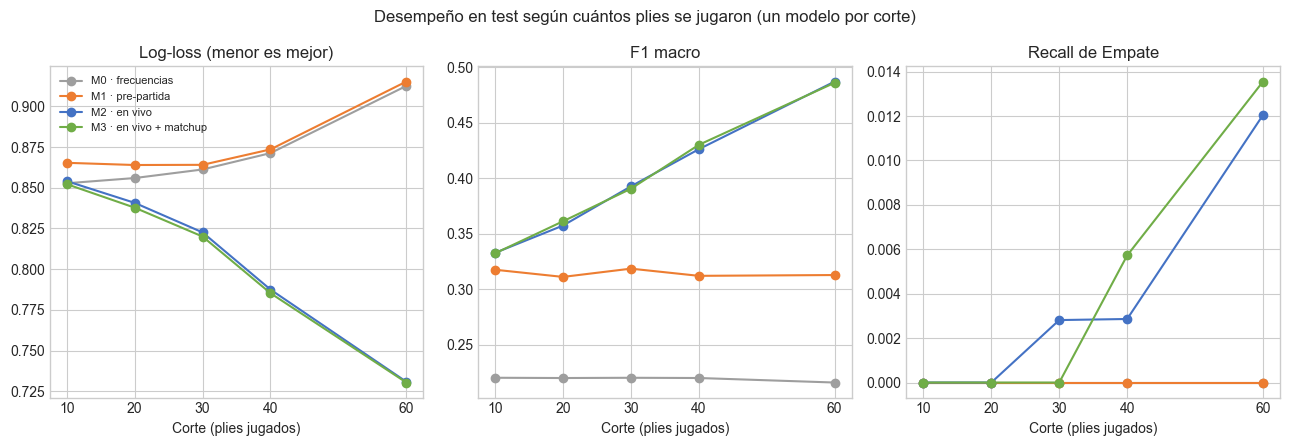

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, metric, title in zip(
    axes, ["log_loss", "f1_macro", "recall_empate"], ["Log-loss (menor es mejor)", "F1 macro", "Recall de Empate"]
):
    for name, color in MODEL_COLORS.items():
        sub = results[results["modelo"] == name]
        ax.plot(sub["corte_ply"], sub[metric], marker="o", color=color, label=name)
    ax.set(title=title, xlabel="Corte (plies jugados)", xticks=CUTS)
axes[0].legend(fontsize=8)
fig.suptitle("Desempeño en test según cuántos plies se jugaron (un modelo por corte)")
plt.tight_layout()
plt.show()

**Lectura de la curva.**

- **Mirar la partida sirve, pero recién después de la apertura.** Al ply 10 el modelo en vivo (M2) empata con el piso: log-loss 0,854 contra 0,853. Desde ahí mejora en cada corte, hasta 0,731 al ply 60 contra 0,913 del piso (−20 %). El F1 macro sube de 0,33 a 0,49.
- **El modelo pre-partida (M1) no mejora las probabilidades.** Su log-loss es algo peor que el piso en todos los cortes (0,865 contra 0,853 al ply 10), aunque su F1 macro es mayor (0,31 contra 0,22, porque el piso siempre predice la clase mayoritaria). Sin el rating del rival, lo que se sabe antes de mover ordena un poco las partidas pero no calibra mejor que las frecuencias. Además, la mezcla de resultados cambia entre train y test (Empate 7,1 % contra 5,5 %).
- **Empate casi nunca se predice.** El recall de Empate queda en ~0 en todos los modelos: con 6 % de tablas, el argmax nunca elige esa clase. Se trata en el punto 5.1.

**Cuidado al leer la curva: sesgo de supervivencia.** Cada corte evalúa una población distinta: al ply 60 sólo quedan las partidas que duraron más de 60 plies (61,9 %), que son distintas de las cortas. Una mejora entre cortes mezcla dos cosas: que el modelo ve más partida y que la población cambió. Para separarlas, la celda siguiente repite la comparación sobre la **población común**, las partidas de test que llegan al último corte, con los mismos modelos ya entrenados.

In [8]:
last_cut = max(CUTS)
common_games = set(data.loc[(data["corte_ply"] == last_cut) & (data["particion"] == "test"), "GameUrl"])
common_rows = []
for cut in CUTS:
    test = data[(data["corte_ply"] == cut) & (data["particion"] == "test") & data["GameUrl"].isin(common_games)]
    train = data[(data["corte_ply"] == cut) & (data["particion"] == "train")]
    y_test = test["resultado"].astype(str)
    common_rows.append({"corte_ply": cut, "modelo": "M0 · frecuencias", **classification_metrics(y_test, frequency_baseline(train, test))})
    for name, columns in FEATURE_SETS.items():
        common_rows.append({"corte_ply": cut, "modelo": name,
                            **classification_metrics(y_test, predict_ordered(fitted[(cut, name)], test, columns))})
common = pd.DataFrame(common_rows)
print(f"Población común: {len(common_games):,} partidas de test que llegan al ply {last_cut}")
display(common.pivot(index="corte_ply", columns="modelo", values="log_loss").round(3))

Población común: 8,451 partidas de test que llegan al ply 60


modelo,M0 · frecuencias,M1 · pre-partida,M2 · en vivo,M3 · en vivo + matchup
corte_ply,,,,
10,0.912,0.941,0.925,0.922
20,0.912,0.934,0.911,0.906
30,0.911,0.925,0.898,0.893
40,0.911,0.920,0.862,0.859
60,0.913,0.915,0.731,0.730


**Lectura (población común).** Sobre las mismas 8.451 partidas en todos los cortes, la ventaja temprana desaparece. Al ply 10 el modelo en vivo es algo **peor** que el piso (0,925 contra 0,912) y al ply 20 empata (0,911 contra 0,912). La mejora aparece desde el ply 30 (0,898) y crece al 40 (0,862) y al 60 (0,731).

Parte de la mejora temprana de la curva general viene entonces de las partidas **cortas**, que se deciden rápido y ya muestran ventaja de material al ply 20. En una partida que va a ser larga, los primeros 20 plies dicen poco. Esta es la versión que hay que presentar: la curva general sola exagera el valor de los cortes tempranos.

### 5.1 · El desbalance de Empate

Con `class_weight="balanced"` el modelo pondera cada clase por la inversa de su frecuencia, así que se anima a predecir tablas. El precio es la calibración: las probabilidades ya no reflejan frecuencias reales, así que la log-loss empeora. Se compara en dos cortes con las variables de M2.

In [9]:
balanced_rows = []
columns = FEATURE_SETS["M2 · en vivo"]
for cut in (20, last_cut):
    train = data[(data["corte_ply"] == cut) & (data["particion"] == "train")]
    test = data[(data["corte_ply"] == cut) & (data["particion"] == "test")]
    y_test = test["resultado"].astype(str)
    weighted = HistGradientBoostingClassifier(categorical_features="from_dtype", class_weight="balanced", random_state=RANDOM_STATE)
    weighted.fit(to_matrix(train, columns), train["resultado"].astype(str))
    for name, model in [("M2 · en vivo", fitted[(cut, "M2 · en vivo")]), ("M2 · balanceado", weighted)]:
        balanced_rows.append({"corte_ply": cut, "modelo": name, **classification_metrics(y_test, predict_ordered(model, test, columns))})
display(pd.DataFrame(balanced_rows).set_index(["corte_ply", "modelo"]).round(3))

log_loss  f1_macro  accuracy_balanceada  \
corte_ply modelo                                                     
20        M2 · en vivo        0.841     0.357                0.367   
          M2 · balanceado     0.981     0.379                0.399   
60        M2 · en vivo        0.731     0.487                0.503   
          M2 · balanceado     0.829     0.535                0.551   

                           recall_empate  
corte_ply modelo                          
20        M2 · en vivo             0.000  
          M2 · balanceado          0.223  
60        M2 · en vivo             0.012  
          M2 · balanceado          0.319

**Lectura.** Es un trade-off, no una mejora gratis. Al ply 60, balancear sube el recall de Empate de 0,012 a 0,319 y el F1 macro de 0,487 a 0,535, pero la log-loss empeora de 0,731 a 0,829. Al ply 20 pasa lo mismo: el recall de Empate va de 0 a 0,223 y la log-loss de 0,841 a 0,981. Cuál conviene depende del producto:

- para mostrar una **probabilidad** en vivo, el modelo sin balancear, porque su log-loss es mejor;
- para **alertar** que una partida va a tablas, el balanceado.

La Entrega 3 tiene que reportar las dos cosas y elegir según ese uso, no sólo por accuracy.

## 6 · Qué variables usa el modelo en vivo

Importancia por permutación del modelo M3 en dos cortes, sobre una muestra de test. La importancia mide cuánto empeora la log-loss al desordenar cada variable. Es importancia **del modelo**, no un efecto causal, y las variables correlacionadas (por ejemplo, los dos relojes y su diferencia) se reparten el crédito.

In [10]:
importance_rows = []
columns = FEATURE_SETS["M3 · en vivo + matchup"]
for cut in (20, last_cut):
    test = data[(data["corte_ply"] == cut) & (data["particion"] == "test")].sample(5000, random_state=RANDOM_STATE)
    imp = permutation_importance(
        fitted[(cut, "M3 · en vivo + matchup")], to_matrix(test, columns), test["resultado"].astype(str),
        scoring="neg_log_loss", n_repeats=3, random_state=RANDOM_STATE,
    )
    importance_rows.append(pd.Series(imp.importances_mean, index=columns, name=f"ply {cut}"))
importance = pd.concat(importance_rows, axis=1).sort_values(f"ply {last_cut}", ascending=False)
display(importance.head(12).round(4))

,ply 20,ply 60
balance_material,0.012,0.207
diferencia_reloj_seg,0.003,0.049
reloj_frac_blancas,0.005,0.036
reloj_negras_seg,0.006,0.032
reloj_blancas_seg,0.004,0.021
reloj_frac_negras,0.002,0.021
movilidad,0.005,0.014
gasto_reciente_negras_seg,0.001,0.010
elo_blancas_previo,0.005,0.007
capturas_negras,-0.000,0.004


**Lectura.** Al ply 60, el **balance de material** domina (0,207 de log-loss perdida al desordenarlo), seguido por los relojes (diferencia de reloj, fracción restante de cada lado). Al ply 20 todas las importancias son chicas, coherente con que en ese corte el modelo casi no supera al piso. El rating previo reconstruido aporta poco en los dos cortes: se conoce sólo un lado, y la posición lo reemplaza a medida que avanza la partida.

## 7 · Matchup de apertura (pedido D): cobertura y aporte

**Definición** (ver `docs/entregas/guia-columnas-y-features.md`): `matchup_apertura` = primera jugada de blancas × respuesta de negras. Son 17 combinaciones congeladas más `otra`, y es una taxonomía del equipo, no ECO. Las tasas históricas usan sólo partidas del mismo matchup y ritmo con `EndTime_previa < StartTime_actual`. Con menos de 30 previas quedan NaN.

Primero, dónde falta historial. Se espera que sea estructural: las primeras 30 partidas de cada grupo, concentradas en los años viejos de la muestra.

In [11]:
missing = ~games["historial_suficiente"]
print(f"Partidas sin historial suficiente: {int(missing.sum()):,} ({missing.mean() * 100:.2f} %)")
display(pd.concat({
    "sin historial": games.loc[missing].groupby(games["Date"].dt.year).size(),
    "total": games.groupby(games["Date"].dt.year).size(),
}, axis=1).fillna(0).astype(int).assign(pct=lambda t: (100 * t["sin historial"] / t["total"]).round(1)).T)
per_group = games.loc[missing].groupby(["matchup_apertura", "TimeClass"], observed=True).size()
print(f"Grupos (matchup × ritmo) con faltantes: {per_group.size}; faltantes por grupo: min {per_group.min()}, max {per_group.max()}")

Partidas sin historial suficiente: 1,620 (2.11 %)


Date,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
sin historial,1.000,316.000,20.000,267.000,133.000,158.000,85.000,217.000,192.000,47.000,99.000,65.000,20.000,0.000
total,1.000,535.000,117.000,555.000,735.000,"1,519.000","1,856.000","5,174.000","4,206.000","2,587.000","5,505.000","7,573.000","12,769.000","33,671.000"
pct,100.000,59.100,17.100,48.100,18.100,10.400,4.600,4.200,4.600,1.800,1.800,0.900,0.200,0.000


Grupos (matchup × ritmo) con faltantes: 54; faltantes por grupo: min 30, max 30


**Lectura.** Los faltantes son exactamente las primeras 30 partidas de cada uno de los 54 grupos (18 matchups × 3 ritmos). No hay un patrón escondido: es la ausencia de historia al principio de la muestra, que tiene más peso en 2014–2021 porque esos años tienen pocas partidas. En el test, que es el período más reciente, no falta ninguna.

Segundo, si la tasa histórica **dice algo** sobre el resultado. Se calibra la tasa histórica de victoria blanca contra la frecuencia real de victoria blanca, por quintiles, en test.

In [12]:
test_games_df = games[games["GameUrl"].isin(test_games) & games["historial_suficiente"]].copy()
test_games_df["quintil_tasa_blancas"] = pd.qcut(test_games_df["tasa_blancas_hist"], 5, duplicates="drop")
calibration = test_games_df.groupby("quintil_tasa_blancas", observed=True).agg(
    partidas=("GameUrl", "size"),
    tasa_hist_media=("tasa_blancas_hist", "mean"),
    gana_blancas_real=("resultado", lambda s: (s == "Gana Blancas").mean()),
)
display(calibration)

ablation = results.pivot(index="corte_ply", columns="modelo", values="log_loss")
ablation["M3 − M2 (log-loss)"] = ablation["M3 · en vivo + matchup"] - ablation["M2 · en vivo"]
display(ablation[["M2 · en vivo", "M3 · en vivo + matchup", "M3 − M2 (log-loss)"]].round(4))

,partidas,tasa_hist_media,gana_blancas_real
quintil_tasa_blancas,,,
"(0.369, 0.468]",3073,0.457,0.502
"(0.468, 0.48]",3072,0.474,0.501
"(0.48, 0.497]",3072,0.488,0.477
"(0.497, 0.506]",3072,0.501,0.485
"(0.506, 0.571]",3072,0.518,0.505


modelo,M2 · en vivo,M3 · en vivo + matchup,M3 − M2 (log-loss)
corte_ply,,,
10,0.854,0.852,-0.002
20,0.841,0.838,-0.003
30,0.823,0.820,-0.003
40,0.787,0.785,-0.002
60,0.731,0.730,-0.001


**Lectura: resultado negativo, bien fundamentado.** La tasa histórica del matchup **no predice** el resultado:

- **Calibración:** entre el quintil más bajo (tasa histórica 0,457) y el más alto (0,518), la victoria blanca real se mueve entre 0,477 y 0,505, sin orden.
- **Ablación:** agregar el matchup y sus tasas (M3 contra M2) mejora la log-loss entre 0,001 y 0,003 según el corte, que es ruido.

Era lo esperado: la victoria blanca casi no varía entre aperturas (48,4 % a 49,8 % entre familias, notebook 02). La feature queda construida, verificada y sin fuga, pero **no entra al modelo principal**. Se documenta como una hipótesis probada y descartada, no como una feature que falta probar.

## 8 · Duración restante

El segundo target del proyecto es la duración. En vivo, la pregunta natural es **cuántos plies faltan** (`plies_restantes`). Se compara un gradient boosting con las variables de M2 contra un baseline: la mediana de train por ritmo en ese corte. La métrica es el error absoluto medio (MAE) en plies.

In [13]:
duration_rows = []
columns = FEATURE_SETS["M2 · en vivo"]
for cut in CUTS:
    train = data[(data["corte_ply"] == cut) & (data["particion"] == "train")]
    test = data[(data["corte_ply"] == cut) & (data["particion"] == "test")]
    medians = train.groupby("TimeClass", observed=True)["plies_restantes"].median()
    baseline = test["TimeClass"].astype(str).map(medians.rename(index=str))
    regressor = HistGradientBoostingRegressor(categorical_features="from_dtype", loss="absolute_error", random_state=RANDOM_STATE)
    regressor.fit(to_matrix(train, columns), train["plies_restantes"])
    duration_rows.append({
        "corte_ply": cut,
        "MAE mediana por ritmo": mean_absolute_error(test["plies_restantes"], baseline),
        "MAE modelo en vivo": mean_absolute_error(test["plies_restantes"], regressor.predict(to_matrix(test, columns))),
    })
duration = pd.DataFrame(duration_rows).set_index("corte_ply")
duration["mejora %"] = 100 * (1 - duration["MAE modelo en vivo"] / duration["MAE mediana por ritmo"])
display(duration.round(2))

,MAE mediana por ritmo,MAE modelo en vivo,mejora %
corte_ply,,,
10,25.850,24.640,4.680
20,24.900,23.530,5.490
30,23.700,22.000,7.170
40,22.300,20.570,7.780
60,19.770,17.460,11.680


**Lectura.** El modelo en vivo le gana a la mediana por ritmo en todos los cortes, pero poco: 4,7 % menos error al ply 10 y 11,7 % al ply 60, con un error absoluto medio de 17 a 25 plies. La duración que falta depende de decisiones que la posición todavía no muestra (cuándo abandonar, cuándo aceptar tablas), así que es un target mucho más difícil que el resultado.

## 9 · Conclusiones

1. **La predicción en vivo funciona, y su valor crece con la partida.** Sobre la misma población, el modelo en vivo empata con el piso hasta el ply 20 y lo supera desde el ply 30: log-loss 0,731 contra 0,913 al ply 60 (−20 %). La curva general exagera los cortes tempranos por sesgo de supervivencia, así que se presenta la de población común.
2. **Lo que decide es el material y el reloj**, no el nivel previo de los jugadores: sin el rating del rival, el modelo pre-partida no calibra mejor que las frecuencias.
3. **Empate sigue siendo el problema del proyecto.** Sin balancear no se predice nunca. Balanceando se gana recall a costa de calibración, y la elección depende del uso.
4. **El histórico de matchups de apertura no aporta** (ablación ±0,003 de log-loss, calibración plana). Queda construido y documentado como resultado negativo.
5. **La duración restante se predice apenas mejor que una mediana** (4,7 % a 11,7 % menos error).

**Limitaciones.**

- Baselines con hiperparámetros por defecto: los números son un piso, no el máximo alcanzable.
- La partición es temporal con los mismos jugadores en train y test. No mide generalización a jugadores nuevos.
- El rating previo sólo se conoce de un lado.
- La muestra son 100 cuentas elegidas por banda, no Chess.com en general.
- El corte al ply 60 sólo describe partidas que llegan hasta ahí.

## 10 · Verificación final

Chequeos automáticos de lo que el análisis dio por supuesto.

In [14]:
assert results.groupby("corte_ply")["modelo"].nunique().eq(4).all(), "Faltan modelos en algún corte"
assert results["log_loss"].notna().all() and np.isfinite(results["log_loss"]).all()
# Sanity bound: the class-frequency baseline can never be worse than a uniform guess (ln 3).
assert (results.loc[results["modelo"] == "M0 · frecuencias", "log_loss"] < np.log(3)).all()
assert set(data.loc[data["particion"] == "train", "GameUrl"]).isdisjoint(data.loc[data["particion"] == "test", "GameUrl"])
assert games.loc[games["GameUrl"].isin(train_games), "EndTime"].max() < games.loc[games["GameUrl"].isin(test_games), "StartTime"].min(), \
    "Una partida de train termina después de que empieza una de test"
assert not set(LEAKY) & {c for cols in FEATURE_SETS.values() for c in cols}
assert (games.loc[~games["historial_suficiente"], ["tasa_blancas_hist", "tasa_tablas_hist", "tasa_negras_hist"]].isna().all().all())
print("Todos los chequeos pasaron.")

Todos los chequeos pasaron.
